In [1]:
import numpy as np
from scipy import special
from copy import deepcopy
import openfermion as of
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.linalg import expm
import matplotlib.pyplot as plt
from time import time
# import qutip as qt
from scipy.linalg import schur, det
from scipy.optimize import curve_fit
from scipy.linalg import sqrtm
import pandas as pd
from tqdm import tqdm
import networkx as nx

This notebook shows the analytical solution to the groundstate preparation of the transverse field ising model(TFIM)

In [2]:
g = 1.5
J = 1
n = 3
#gamma = 5
gap_TFIM = 2*np.abs(1-g)

In [3]:
from functools import reduce

X = np.array([[0,1],[1,0]],dtype='complex128')
Y = np.array([[0,-1j],[1j,0]],dtype='complex128')
Z = np.array([[1,0],[0,-1]],dtype='complex128')
eye = np.eye(2, dtype='complex128')


def tensor(lst):
    return reduce(np.kron, lst)

We start from the TFIM hamiltonian with interaction strength $J$ and transversfield $g$:
$$\hat{H}_{\text{TFIM}}=-g \sum_i^n \hat{\sigma}_i^z-J \sum_{i}^{n-1} \hat{\sigma}_i^x \hat{\sigma}_{i+1}^x$$

In [4]:
def TFIM(L):
    H = np.zeros([2**L,2**L],dtype='complex128')
    for i in range(L):
        termz = tensor([Z if j == i else eye for j in range(L)])
        H += -g * termz
    for i in range(L-1):
        termx = tensor([X if (j == i or j == i + 1) else eye for j in range(L)])
        H += -J*termx
    return sp.csc_matrix(H)


We define a filter $\hat{f(\omega)}$ function supported on the real axis:
$$f(s):=\frac{1}{2 \pi} \int_{\mathbb{R}} \hat{f}(\omega) e^{-i \omega s} \mathrm{~d} \omega, \quad \hat{f}(\omega)=\int_{\mathbb{R}} e^{i \omega s} f(s) \mathrm{d} s$$

In [5]:
def filter_freq(w):
    a = 2.5*E0_TFIM
    b = gap_TFIM/4
    da = 0.1*E0_TFIM
    db = gap_TFIM/4
    f = 1/2*(special.erf((w+a)/da)-special.erf((w+b)/db))
    return f

In [6]:
def filter_time(s):
    a = 2.5*np.abs(E0_TFIM)
    b = gap_TFIM/4
    da = 0.1*np.abs(E0_TFIM)
    db = gap_TFIM/4

    if np.abs(s) < 1e-10:
        f = (a - b) / (2 * np.pi)
    else:
        ex_a = np.exp(-da ** 2 * s ** 2 / 4) * np.exp(1j * a * s)
        ex_b = np.exp(-db ** 2 * s ** 2 / 4) * np.exp(1j * b * s)
        f = (ex_a - ex_b) / (2 * np.pi * 1j * s)
    return f

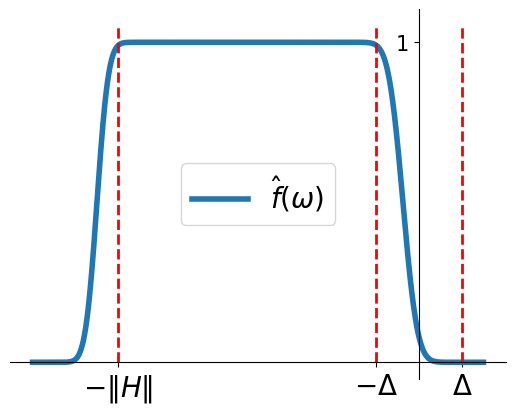

In [7]:
E0_TFIM = 3
gap_TFIM = 1.5

ws = np.linspace(-9, 1.5, 1000)
filt = filter_freq(ws)


fig, ax = plt.subplots()
ax.plot(ws, filt,linewidth=4,label=r'$\hat{f} (\omega)$')

# Hide the right and top spines (removes the outer box)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Move the left and bottom spines to the middle of the plot
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Set the ticks to appear only on the bottom and left
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Optional: remove ticks from top/right
ax.xaxis.set_tick_params(top=False)
ax.yaxis.set_tick_params(right=False)

ax.set_yticks([1])
ax.set_xticks([1, -1, -7])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xticklabels([r'$\Delta$', r'$-\Delta$', r'$-\| H \|$'],fontsize=20)
ax.vlines(-7,0,1.05,color='red', linestyle='dashed',linewidth=2)
ax.vlines(-1,0,1.05,color='red', linestyle='dashed',linewidth=2)
ax.vlines(1,0,1.05,color='red', linestyle='dashed',linewidth=2)
plt.legend(fontsize=20,loc=10)

#ax.ylabel(r'$\hat{f} (\omega)$')
plt.savefig('filter_freq.pdf',bbox_inches='tight')
plt.show()

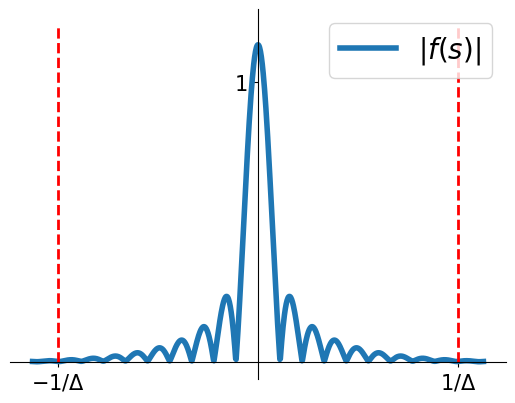

In [8]:
E0_TFIM = 3
gap_TFIM = 1.5

ws = np.linspace(-9, 9, 1000)
filt = np.array([np.abs(filter_time(t)) for t in ws])


fig, ax = plt.subplots()
ax.plot(ws, filt,linewidth=4,label=r'$|f(s)|$')

# Hide the right and top spines (removes the outer box)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Move the left and bottom spines to the middle of the plot
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Set the ticks to appear only on the bottom and left
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Optional: remove ticks from top/right
ax.xaxis.set_tick_params(top=False)
ax.yaxis.set_tick_params(right=False)

ax.set_yticks([1])
ax.set_xticks([-8,8])
ax.set_xticklabels([r'$-1/\Delta$', r'$1/\Delta$'],fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#ax.set_xticklabels([r'$\Delta$', r'$-\Delta$', r'$-\| H \|$'])

ax.vlines(-8,0,1.2,color='red', linestyle='dashed',linewidth=2)
ax.vlines(8,0,1.2,color='red', linestyle='dashed',linewidth=2)
#ax.vlines(1,0,1.05,color='red', linestyle='dashed')
plt.legend(fontsize=20,loc=1)

#ax.ylabel(r'$\hat{f} (\omega)$')
plt.savefig('filter_time.pdf',bbox_inches='tight')
plt.show()

Then the dynamics of the density matrix is given by the Lindbladian
$$\partial_t \hat{\rho}=\mathcal{L}(\hat{\rho})=-\mathrm{i}[\hat{H}, \hat{\rho}]+\sum_k\left(\hat{L}_k \hat{\rho} \hat{L}_k^{\dagger}-\frac{1}{2}\left\{\hat{L}_k^{\dagger} \hat{L}_k, \hat{\rho}\right\}\right),$$

where we use a single jump operator $\hat{L}_k=K$ and
$$K=\int f(s) e^{i H s} A e^{-i H s} \mathrm{~d} s.$$

the coupling matrix $A$ is given by a simple pauli Y on the first qubit (boundry dissipation).

In [9]:
def create_jump_operator(H, A, S, tau_s):
    if sp.issparse(H): H = H.toarray()
    if sp.issparse(A): A = A.toarray()
    H_taus = expm(-1j*tau_s*H)
    M = int(round(S/tau_s))
    A_next = expm(1j*H*(-M*tau_s)) @ A @ expm(-1j*H*(-M*tau_s))
    K = filter_time(-M*tau_s) * A_next * tau_s/2
    for l in range(-M+1,M):
        A_next = H_taus.conj().transpose() @ A_next @ H_taus
        s = l*tau_s
        K += filter_time(s) * A_next * tau_s
    A_next = H_taus.conj().transpose() @ A_next @ H_taus
    K += filter_time(M*tau_s) * A_next * tau_s/2
    return K

We can numerically compute the trajectory of a state $\psi$ using the quantum jump method. We compute $\phi=K\psi$ and $p=||\phi||\tau$. Then with probability $p$ the state becomes $\psi_n=phi/||phi||$ and with probability $1-p$ the next state is $\psi_n=K^\dagger\phi/||k^\dagger\phi||$  

In [10]:
def time_step(psi, tau, H, operators):

    jumpoperators = operators[:-1]
    e_H = operators[-1]
    r = len(jumpoperators)
    events = [i for i in range(r+1)]
    probabilities = []
    states = []
    for K in jumpoperators:
        if K.shape[0] == 1:
            probabilities.append(0)
            states.append(0)
        else:
            phi = K.dot(psi)
            p = np.linalg.norm(phi)**2*tau
            probabilities.append(p)
            states.append(phi)
    sum_p = sum(probabilities)
    if sum_p > 1: print('negative probability')
    probabilities.append(1-sum_p)


    chosen_event = np.random.choice(events, p=probabilities)
    if chosen_event == r:
        psi_n = deepcopy(psi)
        for K_conj, phi in zip(jumpoperators, states):
            if K_conj.shape[0] > 1:
                psi_n += -tau/2*K.conj().transpose().dot(phi)
        psi_n = psi_n / np.linalg.norm(psi_n)
    else:
        #print(chosen_event)
        #print(states[chosen_event])
        psi_n = states[chosen_event]
        psi_n = psi_n / np.linalg.norm(psi_n)
        #print(psi_n)

    psi_n = e_H.dot(psi_n)

    return psi_n

    #K = jumpoperators[:-1]
    #e_H = jumpoperators[-1]
    #phi = K.dot(psi)
    #p = np.linalg.norm(phi)**2*tau
    #rand = np.random.uniform(0.0,1.0)

    #if rand<p:
    #    psi_n = phi/np.linalg.norm(phi)
    #else:
    #    psi_n = psi - 1 / 2 * K.conj().transpose().dot(phi) * tau
    #    psi_n = psi_n/np.linalg.norm(psi_n)

    #psi_n = e_H.dot(psi_n)
    #return psi_n

In [11]:
def trajectory(psi, T, tau, H, operators):
    t = 0
    psi_n = deepcopy(psi)
    energy = []
    while t < T:
        e = np.real(np.dot(psi_n.conj(),H.dot(psi_n)))
        energy.append(e)
        psi_n = time_step(psi_n, tau, H, operators)
        t += tau
    return energy

In [12]:
def random_state(size):

    # Generate random complex Gaussian variables
    real_part = np.random.normal(0, 1, size)
    imaginary_part = np.random.normal(0, 1, size)

    # Combine the real and imaginary parts to create complex numbers
    complex_array = real_part + 1j * imaginary_part

    return complex_array/ np.linalg.norm(complex_array)

In [13]:
def sample_trajectories(N, T, tau, H, operators):
    trajectories = []
    initial_state = np.zeros((H.shape[0]), dtype='complex128')
    initial_state[0] = 1/np.sqrt(2)
    initial_state[1] = 1/np.sqrt(2)
    for i in range(N):
        #print('sample number {}'.format(i))
        trajectories.append(trajectory(initial_state, T, tau, H, operators))
    avg_energy = np.mean(trajectories, axis = 0)
    return avg_energy

Using a Jordan Wigner Transformation the Hamiltonian becomes
$$\hat{H}=\sum_i \left( -J\left(c_i^{\dagger} c_{i+1}+c_{i+1}^{\dagger} c_i+c_i^{\dagger} c_{i+1}^{\dagger}+c_{i+1} c_i\right)- g \left(c_i^{\dagger} c_i-c_i c_i^{\dagger} \right)\right).$$

Now we employ the self adjoint majorana fermions
$$\left(\begin{array}{l}
\hat{w}_{j+} \\
\hat{w}_{j-}
\end{array}\right):=\frac{1}{\sqrt{2}}\left(\begin{array}{cc}
1 & 1 \\
\mathrm{i} & -\mathrm{i}
\end{array}\right)\left(\begin{array}{l}
\hat{c}_j \\
\hat{c}_j^{\dagger}
\end{array}\right) \Leftrightarrow\left(\begin{array}{l}
\hat{c}_j \\
\hat{c}_j^{\dagger}
\end{array}\right)=\frac{1}{\sqrt{2}}\left(\begin{array}{cc}
1 & -\mathrm{i} \\
1 & \mathrm{i}
\end{array}\right)\left(\begin{array}{l}
\hat{w}_{j+} \\
\hat{w}_{j-}.
\end{array}\right)$$

We simplify the notation by 

$$\hat{w}_j:=\hat{w}_{j+} \text { and } \hat{w}_{j+n}:=\hat{w}_{j-}$$

The Hamiltonian becomes

$$\hat{H}=\sum_i\left(-iJ \left(\hat{w}_{i-}\hat{w}_{i+1+} - \hat{w}_{i+} \hat{w}_{i-1-}\right) -ig\left( \hat{w}_{i-}\hat{w}_{i+}-\hat{w}_{i+}\hat{w}_{i-}\right) \right) := \sum_{pq}h_{pq}\hat{w}_{p}\hat{w}_{q},$$

where where $h=h^\dagger=-h^T$.

In [14]:
def h(L):
    H = np.zeros((2*L, 2*L), dtype='complex128')
    for i in range(L):
        H[i, i+L] = -1j*g
        H[L+i, i] = 1j*g
        if i>0:
            H[i, i+L-1] = 1j*J
            H[i+L-1, i] = -1j*J
    return H

In [15]:
def compute_majoranas(L):
    majoranas = [of.FermionOperator(((i,0)),1/np.sqrt(2))+of.FermionOperator(((i,1)),1/np.sqrt(2)) for i in range(L)]
    for i in range(L):
        majoranas.append(of.FermionOperator(((i,0)),1j/np.sqrt(2))+of.FermionOperator(((i,1)),-1j/np.sqrt(2)))
    return majoranas

In [16]:
def hamiltonian(h):
    L = int(len(h[0])/2)
    hamiltonian = of.FermionOperator()
    majoranas = compute_majoranas(L)
    for i, row in enumerate(h):
        for j, value in enumerate(row):
            hamiltonian += value*majoranas[i]*majoranas[j]
    hamiltonian_matrix = of.get_sparse_operator(hamiltonian)
    return hamiltonian_matrix

In [17]:
def ground_energy(H):
    val = np.real(np.linalg.eigvals(H))
    E0 = sum([E for E in val if E<0])
    return E0

In [18]:
def matrix_function(A, f):
    eigenvalues, eigenvectors = np.linalg.eig(A)
    D = np.diag(f(eigenvalues)**2)
    f_A = eigenvectors@D@np.linalg.inv(eigenvectors)

    return f_A

We define the covarience matrix $\Gamma$ which captures all single particle exitations

$$\Gamma_{i, j}:=\frac{1}{2}\left\langle\hat{w}_i \hat{w}_j-\hat{w}_j \hat{w}_i\right\rangle = \mathrm{i}\left\langle\hat{w}_i \hat{w}_j\right\rangle-\frac{\mathrm{i}}{2} \delta_{i, j}.$$

Speficially 

$$E = i\operatorname{TR}[h^T\Gamma],$$

because $\operatorname{TR}[h]=0$.

And, given the covareience matrix $\Gamma^0=i\langle\psi_0|\hat{w}_i \hat{w}_j|\psi_0\rangle-\frac{\mathrm{i}}{2} \delta_{i, j}$, corresponding to the groundstate $|\psi_0\rangle$, we can compute the fidelity as

$$F = \operatorname{TR}[\Gamma^0\Gamma^T-\frac{1}{4}I]$$


In [19]:
def compute_Gamma(psi):
    N = len(psi)
    L = int(np.log2(N))
    majoranas = compute_majoranas(L)
    Gamma = np.diag([-1j/2 for i in range(2*L)])
    for i in range(2*L):
        for j in range(2*L):
            operator = of.get_sparse_operator(1j*majoranas[i]*majoranas[j])
            while operator.shape != (N, N):
                operator = sp.kron(operator, sp.identity(2))
            value = np.dot(psi.conj(), operator.dot(psi))
            Gamma[i,j] += value

    return Gamma

In [20]:
def compute_energy(H, Gamma):
    return np.real(1j*np.trace(H@Gamma))

In [21]:
def compute_fidelity(rho, psi_0):
    return np.dot(psi_0.conj(), np.dot(rho, psi_0))

In [22]:
def trace_distance(rho, sigma):
    # Compute the difference
    delta = rho - sigma
    # Compute the square root of the delta's dagger (conjugate transpose) times delta
    delta_dagger_delta = np.dot(np.conjugate(delta.transpose()), delta)
    sqrt_delta_dagger_delta = sqrtm(delta_dagger_delta)
    # Compute the trace distance
    distance = 0.5 * np.trace(sqrt_delta_dagger_delta)
    return np.real(distance)  # Ensure the result is real since it should be

In [23]:
def compute_entropy(Gamma):
    val = np.real(1j*np.linalg.eigvals(Gamma))
    S = 0
    counter = 0
    #print(val)
    for v in val:
        if v >= 0 and v<0.5:
            S -= (1/2-v)*np.log(1/2-v) + (1/2+v)*np.log(1/2+v)
            counter += 1
            if counter == int(len(val)/2):
                break
    #print(np.round(unique_val, 2))

    return S

The time evolution for $\Gamma$ is given by (Barthel)

$$ \partial_t \Gamma = -2i\left(h\Gamma+\Gamma h^T\right)-\left(\frac{B+B^*}{2} \hat{\Gamma}+\hat{\Gamma} \frac{B+B^*}{2}-\frac{B-B^*}{2 \mathrm{i}}\right),$$

with $B:=\sum_k \boldsymbol{L}_k \boldsymbol{L}_k^{\dagger}$. We can compute

$
        \left[\hat{H}, \hat{w}_i\right]=\sum_{p q} h_{p q}\left[\hat{w}_p \hat{w}_q, \hat{w}_i\right]=\sum_{p q} h_{p q} \hat{w}_p\left\{\hat{w}_q, \hat{w}_i\right\}-\sum_{p q} h_{p q}\left\{\hat{w}_{p q}, \hat{w}_i\right\} \hat{w}_p 
        =\sum_p h_{p i} \hat{w}_p-\sum_q h_{i q} \hat{w}_q=\sum_p\left(h_{p_i}-h_{i_p}\right) \hat{w}_p=\sum_p\left(2 h_{p i}\right) \hat{w}_p 
        := \sum_p\left(\tilde{h}_{p i}\right) \hat{w}_p.
    $
    
Thus 

$e^{\hat{H}} \hat{w}_i=\sum_p \hat{w}_p\left(e^{\tilde{h}}\right)_{p i} e^{\hat{H}}$

and 

$$L_k=\sqrt{2}\int f(s) e^{i H s} w_k e^{-i H s} \mathrm{~d} s=\sqrt{2}\sum_p w_p \int f(s)\left(e^{i \tilde{h} s}\right)_{p k} \mathrm{~d} s=\sqrt{2}\sum_p w_p^{\dagger}[\hat{f}(2h)]_{p k}$$

We choose two jump operators with coupling matrices Pauli $Y_0=i(\hat{c}_0-\hat{c}_0^\dagger)=\sqrt{2}\hat{w}_n$ on the first and $Y_n$ on the last qubit respectively, where

$Y_n=iX_nZ_n=i(\hat{c}_n+\hat{c}_n^\dagger)\Pi_{i=0}^{n} Z_i=i\sqrt{2}\hat{w}_{n-1}P$,
with 
$P=\Pi_{i=1}^n Z_i$
Then we have two the jumpoperators $K_1=L_n$ and $K_2=iL_{n-1}P$. We notice
$$ K_2\rho K_2^\dagger = L_{n-1}P\rho PL_{n-1}^\dagger = L_{n-1}\rho L_{n-1}^\dagger $$
and
$$ K_2^\dagger K_2 \rho = PL_{n-1}^\dagger L_{n-1}P \rho = L_{n-1}^\dagger L_{n-1} \rho$$




therefore $B_{ij} = 2\left([\hat{f}(2h)]_{i n}[\hat{f}(2h)]_{j n}^* + [\hat{f}(2h)]_{i n-1}[\hat{f}(2h)]_{j n-1}^*\right)$

In [24]:
def compute_F(H, dissipation_type='boundary1d'):
    n = int(len(H[0])/2)
    f_h = np.sqrt(2)*matrix_function(2*H, filter_freq)
    gamma = 1
    if dissipation_type == 'bulk':
        F = np.zeros((2*n,2*n), dtype='complex128')
        for i in range(2*n):
            x_vec = f_h[:, i]
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])

    #boundary dissipation
    elif dissipation_type == 'boundary1d':
        F = np.zeros((2*n,2*n), dtype='complex128')
        #x_vec = f_h[:, 0]
        #F = np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, n-1]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, n]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        #x_vec = f_h[:,2*n-1]
        #F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
    elif dissipation_type == 'all_boundary1d':
        F = np.zeros((2*n,2*n), dtype='complex128')
        x_vec = f_h[:, 0]
        F = np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, n-1]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, n]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:,2*n-1]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
    #pure boundary dissipation
    elif dissipation_type == 'pure_boundary1d':
        x_vec = np.zeros((2*n), dtype='complex128')
        x_vec[0] = np.sqrt(2)*np.sqrt(gamma)
        x_vec[n] = -1j*np.sqrt(2)*np.sqrt(gamma)
        F = np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = np.zeros((2*n), dtype='complex128')
        x_vec[n-1] = np.sqrt(2)*np.sqrt(gamma)
        x_vec[2*n-1] = -1j*np.sqrt(2)*np.sqrt(gamma)
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])

    elif dissipation_type == 'boundary2d':
        L = int(np.sqrt(n))
        F = np.zeros((2*n,2*n), dtype='complex128')
        for i in range(L):
            x_vec = f_h[:, i]
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            x_vec = f_h[:, n-L+i]
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            if i>0 and i<(L-1):
                x_vec = f_h[:, i*L]
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
                x_vec = f_h[:, i*L+(L-1)]
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])


    elif dissipation_type == 'spinful_boundary1d':
        L = int(n/2)
        x_vec = f_h[:, L]
        F = np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, L-1]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, 3*L]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        x_vec = f_h[:, 3*L-1]
        F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])


    elif dissipation_type == 'spinful_boundary2d':
        L = int(np.sqrt(n/2))
        F = np.zeros((2*n,2*n), dtype='complex128')
        for i in range(L):
            x_vec = f_h[:, i]
            #print(i)
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            x_vec = f_h[:, int(n/2)-L+i]
            #print(int(n/2)-L+i)
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            if i>0 and i<(L-1):
                x_vec = f_h[:, i*L]
                #print(i*L)
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
                x_vec = f_h[:, i*L+(L-1)]
                #print(i*L+(L-1))
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
        for i in range(2*L**2, 2*L**2+L):
            x_vec = f_h[:, i]
            #print(i)
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            x_vec = f_h[:, int(n/2)-L+i]
            #print(int(n/2)-L+i)
            F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
            if i>2*L**2 and i<(2*L**2+L-1):
                j= i-2*L**2
                x_vec = f_h[:, 2*L**2+j*L]
                #print(2*L**2+j*L)
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
                x_vec = f_h[:, 2*L**2+j*L+(L-1)]
                #print(2*L**2+j*L+(L-1))
                F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])


    else:
        print('unknown dissipation type')
        return None

    F_conj = F.conj()
    F_real = (F+F.conj())/2
    F_im = (F-F.conj())/(2j)
    #print(np.round(F-F.conj().transpose(), 2))

    return F_real, F_im

In [25]:
def pde(t, y):
    result = np.zeros((y.shape), dtype='complex128')
    coherent_term = -2j*(H@y+y@H.transpose())
    linear_term = -(F_real@y+y@F_real-F_im)
    #quadratic_term = 2*(2*M@y@M-M_sq@y-y@M_sq)
    result += coherent_term
    result += linear_term
    #result += quadratic_term
    return result

def pde_nocoherent(t, y):
    result = np.zeros((y.shape), dtype='complex128')
    linear_term = -(F_real@y+y@F_real-F_im)
    #quadratic_term = 2*(2*M@y@M-M_sq@y-y@M_sq)
    result += linear_term
    #result += quadratic_term
    return result

In [26]:
def euler_method(f, y0, t0, t1, h):
    t = deepcopy(t0)
    y = deepcopy(y0)
    while t < t1:
        y = y + h*f(t,y)
        t += h
    return y

In [27]:
def dopri5(f, y0, t_initial, t_final, h=0.01, atol=1e-6, rtol=1e-6):
    a = np.array([0, 1 / 5, 3 / 10, 4 / 5, 8 / 9, 1, 1])
    b = np.array([[0, 0, 0, 0, 0, 0, 0],
                  [1 / 5, 0, 0, 0, 0, 0, 0],
                  [3 / 40, 9 / 40, 0, 0, 0, 0, 0],
                  [44 / 45, -56 / 15, 32 / 9, 0, 0, 0, 0],
                  [19372 / 6561, -25360 / 2187, 64448 / 6561, -212 / 729, 0, 0, 0],
                  [9017 / 3168, -355 / 33, 46732 / 5247, 49 / 176, -5103 / 18656, 0, 0],
                  [35 / 384, 0, 500 / 1113, 125 / 192, -2187 / 6784, 11 / 84, 0]])
    c = np.array([35 / 384, 0, 500 / 1113, 125 / 192, -2187 / 6784, 11 / 84, 0])
    c_star = np.array([5179 / 57600, 0, 7571 / 16695, 393 / 640, -92097 / 339200, 187 / 2100, 1 / 40])

    t, y = t_initial, deepcopy(y0)
    t_end = t_final
    h_lst = []
    N = len(y0)

    if t_final < t_initial and h > 0:
        h = -h  # Set step size to negative for backward evolution
    while (h > 0 and t < t_end) or (h < 0 and t > t_end):
        if (h > 0 and t + h > t_end) or (h < 0 and t + h < t_end):
            h = t_end - t

        k = np.zeros((7, N, N), dtype=complex)

        for i in range(7):
            t_i = t + a[i] * h
            y_i = y.copy()
            for j in range(i):
                y_i += h * b[i, j] * k[j]
            k[i] = f(t_i, y_i)


        y_next = y.copy()
        for i in range(7):
            y_next += h * c[i] * k[i]

        y_star = y.copy()
        for i in range(7):
            y_star += h * c_star[i] * k[i]

        diff = np.abs(y_next-y_star)
        scale = atol + rtol * np.maximum(np.abs(y_next), np.abs(y_star))
        err = np.linalg.norm(diff/scale, ord=2)/np.sqrt(N)

        rho = (1/err)**0.2



        if err <= 1:
            h_lst.append(h)
            t = t + h
            y = y_next
        fac = min(2, max(0.8 * rho, 0.5))
        h = fac*h

    return y

In [28]:
def trajectory_exact(H, Gamma0, T, tau, observable='energy'):
    times = np.linspace(0,T,int(T/tau))
    trajectory = []
    Gamma = deepcopy(Gamma0)
    val, vec = np.linalg.eigh(H)
    diag = np.diag([i/np.abs(i)*0.5j for i in val])
    gamma_ground = vec@diag@vec.conj().transpose()
    for t in tqdm(times):
        if observable=='energy':
            trajectory.append(compute_energy(H, Gamma))
        elif observable=='entropy':
            trajectory.append(compute_entropy(Gamma))
        elif observable=='frobenius':
            norm = np.linalg.norm(gamma_ground@Gamma)
            trajectory.append(norm)
        elif observable=='gamma':
            trajectory.append(Gamma)
        else:
            print('unknown observable')
        Gamma = dopri5(pde, Gamma, 0, tau, h=tau/10)

    return np.array(trajectory)

def trajectory_exact_nocoherent(H, Gamma0, T, tau, observable='energy'):
    times = np.linspace(0,T,int(T/tau))
    trajectory = []
    Gamma = deepcopy(Gamma0)
    val, vec = np.linalg.eigh(H)
    diag = np.diag([i/np.abs(i)*0.5j for i in val])
    gamma_ground = vec@diag@vec.conj().transpose()
    for t in tqdm(times):
        if observable=='energy':
            trajectory.append(compute_energy(H, Gamma))
        elif observable=='entropy':
            trajectory.append(compute_entropy(Gamma))
        elif observable=='frobenius':
            norm = np.linalg.norm(gamma_ground@Gamma)
            trajectory.append(norm)
        elif observable=='gamma':
            trajectory.append(Gamma)
        else:
            print('unknown observable')
        Gamma = dopri5(pde_nocoherent, Gamma, 0, tau, h=tau/10)

    return np.array(trajectory)

Now that we can solve the differential equation for $\Gamma$ directly we don't need to do computations in the $2^n$ dimensional Hilbertspace. Instead all matrices are of size $2nx2n$. This allows us to scale up the system sizes.

In [34]:
T = 2500
tau = 0.1
t = np.linspace(0,T,int(T/tau))
qubits_dyn = [10,20,30,40]
gaps_fit = []
mixing_times = []
eps = 0.5
data = np.zeros((4,25000))
fitdata = np.zeros((4,25000))
var = 0
for n in qubits_dyn:
    print('n =', n)

    H = h(n)
    val = np.sort(np.real(np.linalg.eigvals(H)))
    valm = val[:n]
    valp = 2*val[n:]
    E0=sum(valm)

    #print(E0+np.array(valp))
    #H_matrix = hamiltonian(H)
    #val = eigsh(H_matrix, k=2, which='LM', return_eigenvectors=False)
    #E0_TFIM = min(val)
    E0_TFIM = ground_energy(H)
    #print(E0_TFIM-min(val))
    F_real, F_im = compute_F(H, 'all_boundary1d')

    Gamma0 = np.zeros((2*n,2*n), dtype='complex128')

    distance_exact = trajectory_exact(H, Gamma0, T, tau, observable='energy')
    #np.savetxt('TFIM_{}.txt'.format(n), distance_exact, fmt='%.8f')

    plot = (distance_exact-E0_TFIM)/n
    data[var,:] = plot

    y_lim_top = plot[0]+1


    #index = np.argmax(plot < eps)
    # Corresponding time value
    #mixing_times.append(t[index])

    # choose indices for fit. energy difference should be much smaller than the gap and bigger than computational limit.
    indices = np.where((plot > 1e-8) & (plot < 5e-2))
    m, b = np.polyfit(t[indices], np.log(plot[indices]),1)
    fitdata[var,:] = np.exp(b)*np.exp(m*t)

    gaps_fit.append(-1/m)
    var = var + 1
    #data_min = np.min(distance_exact)
    #data_range = np.abs(np.max(distance_exact) - ground_energy(n))
np.save("data_TFIM.npy", data)
np.save("fitdata_TFIM.npy", fitdata)
np.save("gaps_fit_TFIM.npy", gaps_fit)
np.save("mixing_times_TFIM.npy", mixing_times)


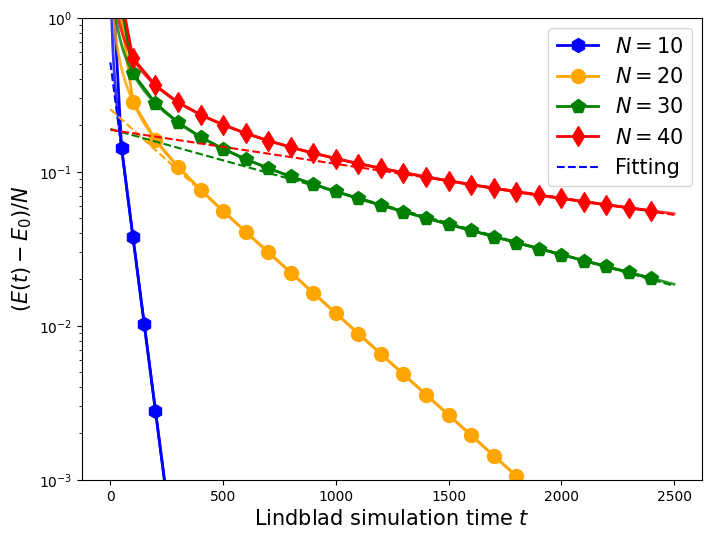

In [29]:
data_load=np.load("data_TFIM.npy")
#fitdata_load=np.load("fitdata_TFIM.npy")

T = 2500
tau = 0.1
t = np.linspace(0,T,int(T/tau))
var = 0
fitdata_load = np.zeros((4,25000))
gaps_fit = []
qubits_dyn = [10,20,30,40]

for n in qubits_dyn:
    plot = data_load[var,:]
    indices = np.where((plot > 1e-7) & (plot < 1e-1))
    m, b = np.polyfit(t[indices], np.log(plot[indices]),1)
    fitdata_load[var,:] = np.exp(b)*np.exp(m*t)

    gaps_fit.append(-1/m)
    var = var + 1



plt.figure(figsize=(8, 6))
plt.plot(t, data_load[0,:], alpha=0.8, linewidth=2, color='blue')
plt.plot(t[::500], data_load[0,::500], marker='h', markersize=10, linewidth=2, color='blue', label=r"$N=10$")
plt.plot(t, data_load[1,:], alpha=0.8, linewidth=2, color='orange')
plt.plot(t[::1000], data_load[1,::1000], marker='o', markersize=10, linewidth=2, color='orange', label=r"$N=20$")
plt.plot(t, data_load[2,:], alpha=0.8, linewidth=2, color='green')
plt.plot(t[::1000], data_load[2,::1000], marker='p', markersize=10, linewidth=2, color='green', label=r"$N=30$")
plt.plot(t, data_load[3,:], alpha=0.8, linewidth=2, color='red')
plt.plot(t[::1000], data_load[3,::1000], marker='d', markersize=10, linewidth=2, color='red', label=r"$N=40$")

plt.plot(t, fitdata_load[0,:], color='blue', linestyle='dashed', label='Fitting')
plt.plot(t, fitdata_load[1,:], color='orange', linestyle='dashed')
plt.plot(t, fitdata_load[2,:], color='green', linestyle='dashed')
plt.plot(t, fitdata_load[3,:], color='red', linestyle='dashed')

plt.yscale('log')
#plt.hlines(eps, 0, t[-1], color='grey', label='epsilon')
plt.ylim(bottom=1e-3, top=1e-0)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=15)
plt.xlabel(r'Lindblad simulation time $t$',fontsize=15)
plt.ylabel(r'$(E(t)-E_0)/N$',fontsize=15)
plt.savefig('tfim_dynamics_diff_ini.pdf', format='pdf',bbox_inches='tight')

We can also calculate the gap directly from computing the jordan normal form of $X_0 = -2iH-B_r$. $B_r$ is the real part of $B$. As the jordan normal form is numerically not stable we use a shur transform instead. The gap is given by the largest real part of the spectrum.

In [30]:
def quasi_free_gap(H, F_real):
    X0 = -2j*H-F_real
    #print(np.round(np.abs(X0), 2))
    #split_matrix_into_blocks(F_real)
    T, Z = schur(X0)
    #print(np.round(T, 2))
    val = np.sort(np.real(np.diag(T)))
    #print(np.round(val,2))
    return np.abs(val[-1]+val[-2])

In [31]:
gaps_qf = []
qubits_qf = np.array([i for i in range(3, 100)])
for n in qubits_qf:
    g=1.5
    H = h(n)
    F_real, F_im = compute_F(H, 'all_boundary1d')
    gap = quasi_free_gap(H, F_real)
    gaps_qf.append(gap)
tmix_qf = 1/np.array(gaps_qf)
fit_range = int(2*len(qubits_qf)/3)
m_qf, b = np.polyfit(np.log(qubits_qf[fit_range:]), np.log(tmix_qf[fit_range:]), 1)
qf_fit = np.exp(b)*np.exp(m_qf*np.log(qubits_qf))
print('Gap Scaling:', m_qf)

Gap Scaling: 3.01850315326584


In [32]:
np.log(gaps_fit)


array([3.64795991, 5.79407624, 6.97176936, 7.58376862])

In [33]:
np.log(qubits_dyn)

array([2.30258509, 2.99573227, 3.40119738, 3.68887945])

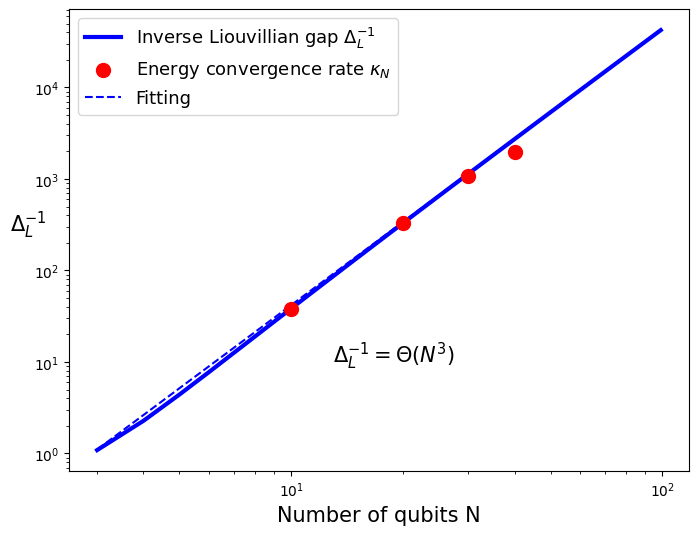

In [34]:
#gaps_fit_load=np.load("gaps_fit_TFIM.npy")

gaps_fit_load=gaps_fit

qubits_dyn = [10,20,30,40]
plt.figure(figsize=(8, 6))
plt.loglog(qubits_qf, tmix_qf,label=r'Inverse Liouvillian gap $\Delta^{-1}_L$', linewidth=3, color='blue')
plt.scatter(qubits_dyn, np.array(gaps_fit_load), label=r'Energy convergence rate $\kappa_N$',color='red',s=100,zorder=5)
#plt.scatter(qubits_TN, np.array(tmix_tn_fit), label = 'mixing time')
plt.plot(qubits_qf, qf_fit, linewidth=1.5,linestyle='dashed', color='blue', label='Fitting'.format((np.round(m_qf, 1))))
plt.text(
    13, 10,  # (x, y) coordinates for the text
    r'$\Delta^{-1}_L=\Theta(N^3)$',  # Text to display
    fontsize=15,
    color='black',
    # bbox=dict(facecolor='white', boxstyle='round,pad=0.01')  # Box style
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel(r'$\Delta^{-1}_L$',fontsize=15,rotation=0)
plt.xlabel(r'Number of qubits N',fontsize=15)
plt.legend(fontsize=13,loc=2)
plt.savefig('scaling_TFIM_diff_ini.pdf', format='pdf',bbox_inches='tight')

In [35]:

n= 10
T = 2000
tau = 0.1
t = np.linspace(0,T,int(T/tau))
H = h(n)
E_ground = ground_energy(H)
F = np.zeros((2*n,2*n),dtype='complex128')
f_h = np.sqrt(2)*matrix_function(2*H, filter_freq)
jump=[0,n,2*n-1,n-1]
for i in jump:
    x_vec = f_h[:, i]
    F += np.dot(x_vec[:, np.newaxis], x_vec.conj()[np.newaxis, :])
F_real = np.real(F)
F_im = np.imag(F)
#Gamma0 is the maxamilly mixed state
Gamma0 = np.zeros((2*n,2*n), dtype='complex128') #maximally mixed state
#nocoherent
energy = trajectory_exact_nocoherent(H, Gamma0, T, tau, observable='energy')
plot_nocoherent = (energy-E_ground)/n
#coherent
energy = trajectory_exact(H, Gamma0, T, tau, observable='energy')
plot = (energy-E_ground)/n

np.save("energy_no_coherent.npy", plot_nocoherent)
np.save("energy_with_coherent.npy", plot)

 28%|██▊       | 5504/20000 [00:03<00:09, 1461.69it/s]/var/folders/nk/mb1mp7ld4nqg1czmpdjmppr80000gn/T/ipykernel_1120/4206087781.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  rho = (1/err)**0.2
100%|██████████| 20000/20000 [00:18<00:00, 1110.73it/s]


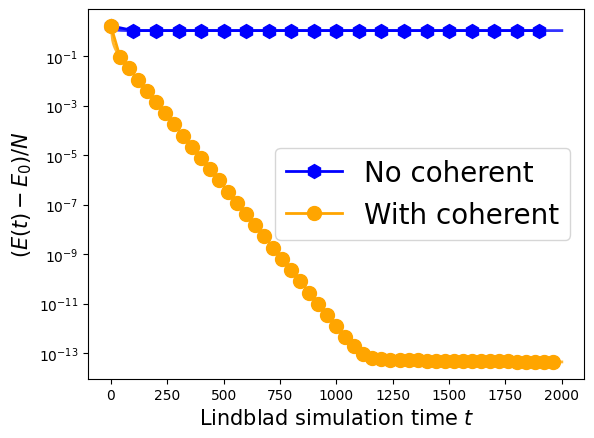

In [36]:
T = 2000
tau = 0.1
t = np.linspace(0,T,int(T/tau))
energy_nc_load=np.load("energy_no_coherent.npy")
energy_c_load=np.load("energy_with_coherent.npy")
plt.plot(t, energy_nc_load, alpha=0.8, linewidth=2, color='blue')
plt.plot(t[::1000], energy_nc_load[::1000], marker='h', markersize=10, linewidth=2, color='blue', label=r"No coherent")
plt.plot(t, energy_c_load, alpha=0.8, linewidth=2, color='orange')
plt.plot(t[::400], energy_c_load[::400], marker='o', markersize=10, linewidth=2, color='orange', label=r"With coherent")
plt.yscale('log')
#plt.hlines(eps, 0, t[-1], color='grey', label='epsilon')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=20)
plt.xlabel(r'Lindblad simulation time $t$',fontsize=15)
plt.ylabel(r'$(E(t)-E_0)/N$',fontsize=15)
plt.savefig('tfim_coherent_check.pdf', format='pdf',bbox_inches='tight')

plt.show()

Check Quasi-locality of $X_1$

We note
$K_a =\int_{-\infty}^{\infty} f(s) e^{iHs} w_a e^{-iHs} \mathrm{d}s=\sum_p [\hat{f}(-2h)]_{a,p}w_p.$


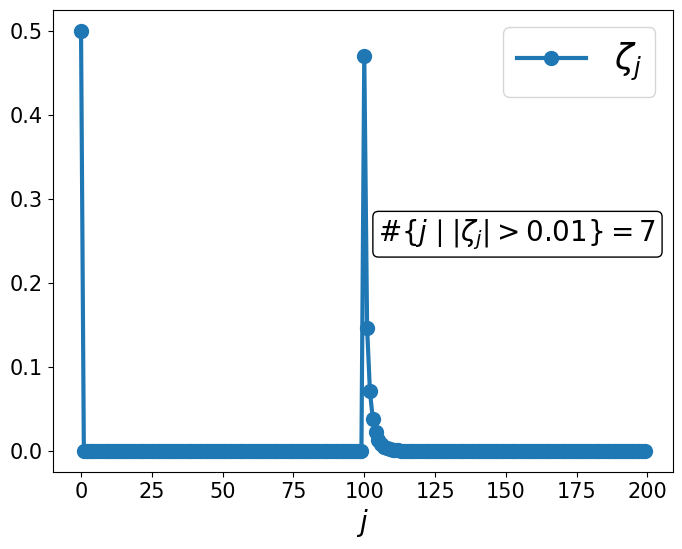

In [37]:
nqbit=100
H=h(nqbit)
mat = np.zeros((2*nqbit,2*nqbit))
eigenvalues, eigenvectors = np.linalg.eig(H)

for i in range(2*nqbit):
    vec = eigenvectors[:,i]
    mat = mat + filter_freq(-2*eigenvalues[i])*np.kron(vec[:, np.newaxis], vec.conj()[np.newaxis, :])
vec=mat[0,:]
# vec1=np.zeros(2*nqbit)

# for i in range(nqbit):
#     vec1[2*i]=np.absolute(vec[i])
#     vec1[2*i+1]=np.absolute(vec[nqbit+i])
plt.figure(figsize=(8, 6))  # Set figure size
plt.plot(np.absolute(vec), marker='o', markersize=10, linewidth=3, linestyle='-', label=r'$\zeta_j$')

# Count elements where |ζ_j| > 0.01
count = np.sum(np.abs(vec) > 0.01)

# Improved text placement
plt.text(
    105, max(np.abs(vec)) * 0.5,  # Dynamically adjust position
    rf'$\#\{{j \mid |\zeta_j| > 0.01\}} = {count}$',  # Proper LaTeX format
    fontsize=20,
    color='black',
    bbox=dict(facecolor='white', boxstyle='round,pad=0.2')  # Box style for better readability
)

plt.xlabel(r'$j$', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=25)  # Adjusted font size
plt.savefig('tfim_quasi_locality.pdf', format='pdf',bbox_inches='tight')
plt.show()